In [3]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib

In [4]:
train_df = pd.read_csv('train_processed.csv')
feature_cols = joblib.load('feature_columns.pkl')

In [5]:
len(feature_cols)

17

In [6]:
train_df.shape

(20631, 21)

In [7]:
X = train_df[feature_cols]
y = train_df['RUL']

In [8]:
X.shape

(20631, 17)

In [9]:
y.shape

(20631,)

In [10]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
print(f"  Training samples: {len(X_train):,}")
print(f"  Validation samples: {len(X_val):,}")

  Training samples: 16,504
  Validation samples: 4,127


# **Random Forest**

In [12]:
rf_model = RandomForestRegressor(
    n_estimators=100,        # Number of trees in the forest
    max_depth=20,            # Maximum depth of each tree
    min_samples_split=5,     # Minimum samples to split a node
    min_samples_leaf=2,      # Minimum samples in leaf node
    random_state=42,
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

In [13]:
rf_model.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    9.4s finished


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [14]:
rf_train_pred = rf_model.predict(X_train)
rf_val_pred = rf_model.predict(X_val)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.1s


[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.1s finished


In [15]:
rf_train_rmse = np.sqrt(mean_squared_error(y_train, rf_train_pred))
rf_train_mae = mean_absolute_error(y_train, rf_train_pred)
rf_train_r2 = r2_score(y_train, rf_train_pred)

In [16]:
rf_val_rmse = np.sqrt(mean_squared_error(y_val, rf_val_pred))
rf_val_mae = mean_absolute_error(y_val, rf_val_pred)
rf_val_r2 = r2_score(y_val, rf_val_pred)

In [17]:
print(f"\n Random Forest Results:")
print(f"\nTraining Set:")
print(f"  RMSE: {rf_train_rmse:.2f} cycles")
print(f"  MAE:  {rf_train_mae:.2f} cycles")
print(f"  R²:   {rf_train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  RMSE: {rf_val_rmse:.2f} cycles")
print(f"  MAE:  {rf_val_mae:.2f} cycles")
print(f"  R²:   {rf_val_r2:.4f}")


 Random Forest Results:

Training Set:
  RMSE: 20.02 cycles
  MAE:  13.67 cycles
  R²:   0.9163

Validation Set:
  RMSE: 41.37 cycles
  MAE:  29.48 cycles
  R²:   0.6254


# **XGBoost**

In [18]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,        # Number of boosting rounds
    max_depth=10,            # Maximum tree depth
    learning_rate=0.1,       # Step size shrinkage
    subsample=0.8,           # Fraction of samples per tree
    colsample_bytree=0.8,    # Fraction of features per tree
    random_state=42,
    n_jobs=-1
)

In [19]:
xgb_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [20]:
# Predictions
xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred = xgb_model.predict(X_val)

In [21]:
# Train Metrics
xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_train_mae = mean_absolute_error(y_train, xgb_train_pred)
xgb_train_r2 = r2_score(y_train, xgb_train_pred)

In [22]:
# Val Metrics
xgb_val_rmse = np.sqrt(mean_squared_error(y_val, xgb_val_pred))
xgb_val_mae = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_r2 = r2_score(y_val, xgb_val_pred)

In [23]:
print(f"\n XGBoost Results:")
print(f"\nTraining Set:")
print(f"  RMSE: {xgb_train_rmse:.2f} cycles")
print(f"  MAE:  {xgb_train_mae:.2f} cycles")
print(f"  R²:   {xgb_train_r2:.4f}")
print(f"\nValidation Set:")
print(f"  RMSE: {xgb_val_rmse:.2f} cycles")
print(f"  MAE:  {xgb_val_mae:.2f} cycles")
print(f"  R²:   {xgb_val_r2:.4f}")


 XGBoost Results:

Training Set:
  RMSE: 15.86 cycles
  MAE:  11.16 cycles
  R²:   0.9474

Validation Set:
  RMSE: 42.34 cycles
  MAE:  30.22 cycles
  R²:   0.6076


# **Comparison Visualization**

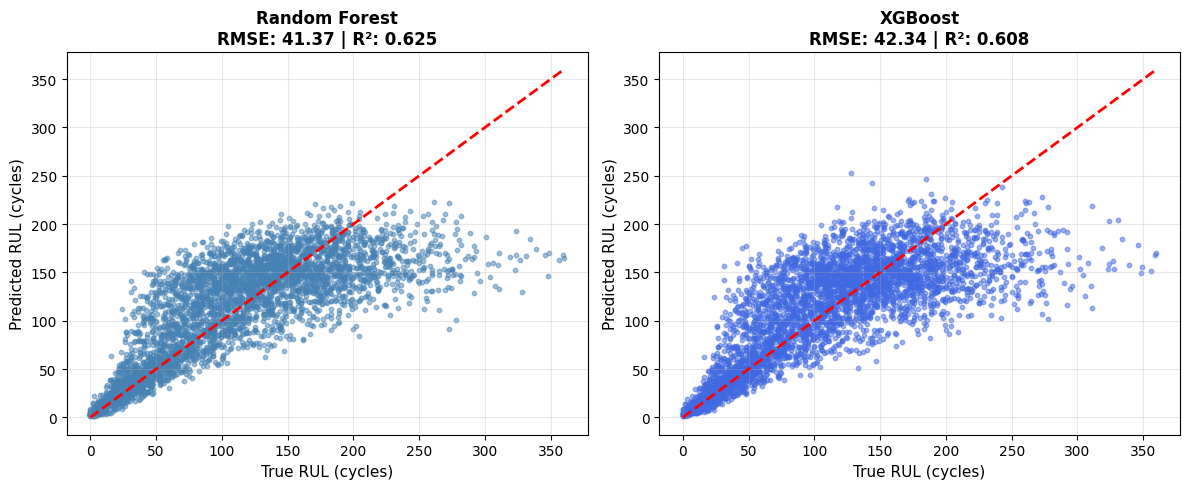

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Random Forest
axes[0].scatter(y_val, rf_val_pred, alpha=0.5, s=10, color='steelblue')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[0].set_xlabel('True RUL (cycles)', fontsize=11)
axes[0].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[0].set_title(f'Random Forest\nRMSE: {rf_val_rmse:.2f} | R²: {rf_val_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# XGBoost
axes[1].scatter(y_val, xgb_val_pred, alpha=0.5, s=10, color='royalblue')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('True RUL (cycles)', fontsize=11)
axes[1].set_ylabel('Predicted RUL (cycles)', fontsize=11)
axes[1].set_title(f'XGBoost\nRMSE: {xgb_val_rmse:.2f} | R²: {xgb_val_r2:.3f}',
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()